# 06D - Emotion2Vec Co-Attention Full SER

Notebook này là bản nâng cấp từ hướng `06 Advanced Multi-Representation Domain-Robust SER`, nhưng đổi trọng tâm từ **adversarial ablation** sang **biểu diễn cảm xúc mạnh hơn + fusion tốt hơn**.

Mục tiêu chính:

- dùng `emotion2vec` ở chế độ **frozen embedding** để lấy biểu diễn cảm xúc từ waveform;
- giữ lại nhánh temporal acoustic, spectrogram và statistical features của hệ thống hiện tại;
- thay concat-fusion thô bằng **lightweight co-attention fusion**;
- dùng thêm `RBF-SVM` và head riêng trên emotion2vec để stacking ở cuối;
- đánh giá trên `combined_random` và `combined_strict_no_tess`.

6 nhãn cảm xúc:

```text
neutral, happy, sad, angry, fear, disgust
```


## Ý Tưởng Và Paper Reference

### 1. emotion2vec frozen embedding

`emotion2vec` học biểu diễn cảm xúc phổ quát từ speech. Trong notebook này mô hình pretrained được giữ **frozen**, nghĩa là ta không fine-tune toàn bộ model, chỉ train adapter/classifier nhỏ ở phía sau. Cách này hợp với Kaggle vì nhẹ hơn và ít overfit hơn khi dataset SER không quá lớn.

Reference:

- emotion2vec: Self-Supervised Pre-Training for Speech Emotion Representation, https://arxiv.org/abs/2312.15185
- ModelScope emotion2vec, https://www.modelscope.cn/models/iic/emotion2vec_base

### 2. Co-attention fusion

CA-MSER cho thấy việc fusion nhiều representation nên để các nhánh tương tác với nhau, thay vì chỉ concatenate vector. Ở đây dùng phiên bản nhẹ:

```text
Query  = z_emotion2vec
Key    = [z_temporal, z_spectral]
Value  = [z_temporal, z_spectral]
```

Nghĩa là embedding emotion2vec đóng vai trò hỏi: "trong temporal/spectral branch, phần nào hữu ích cho cảm xúc hiện tại?"

Reference:

- CA-MSER: Speech Emotion Recognition with Co-Attention based Multi-level Acoustic Information, https://arxiv.org/abs/2203.15326

### 3. Statistical features + RBF-SVM

Các paper baseline mạnh thường dùng handcrafted/statistical features rất kỹ. Vì vậy notebook vẫn giữ một nhánh thống kê riêng, rồi train `RBF-SVM` trên vector này. SVM không thay deep model, mà đóng vai trò model bổ sung cho stacking.

Reference liên quan:

- Ahmed et al. ensemble 1D-CNN/CNN-LSTM/CNN-GRU, https://arxiv.org/abs/2112.05666
- Ullah et al. feature fusion 1D-CNN, https://doi.org/10.1109/ICIT56493.2022.9989197

### 4. Stacking

Deep co-attention model, stats SVM và emotion2vec head có điểm mạnh khác nhau. Stacking học cách kết hợp xác suất dự đoán trên validation split:

$$
p_{final} = C_{meta}([p_{deep}; p_{stats}; p_{e2v}])
$$

Meta-classifier chỉ được fit trên validation predictions, không dùng test để tránh leakage.


## Kiến Trúc Full

```text
Input audio 16 kHz
   |
   |-- Branch A: Temporal acoustic
   |      MFCC + delta + delta-delta + RMS/ZCR/spectral sequence
   |      -> 1D-CNN -> BiLSTM -> attention pooling
   |      -> z_temporal
   |
   |-- Branch B: Spectrogram
   |      log-Mel + delta log-Mel + delta-delta log-Mel
   |      -> 2D-CNN / small residual CNN + SE attention
   |      -> z_spectral
   |
   |-- Branch C: Emotion pretrained
   |      raw waveform
   |      -> frozen emotion2vec
   |      -> adapter MLP
   |      -> z_emotion2vec
   |
   |-- Branch D: Statistical
          handcrafted statistical vector
          -> Stats MLP -> z_stats
          -> RBF-SVM -> p_stats

Fusion:
   z_emotion2vec queries z_temporal and z_spectral
   -> lightweight co-attention
   -> fusion MLP
   -> p_deep

Final:
   stacking / validation-weighted ensemble
   -> p_final
   -> predicted emotion + confidence
```


## Kaggle Run Guide

Dataset cần add vào notebook:

1. `ser_processed` có `metadata.csv` và tốt nhất có `audio_16k/`.
2. Bật Internet nếu muốn tự tải `funasr/modelscope` và model emotion2vec.

Quick smoke test:

```text
QUICK_RUN=1
MAX_EPOCHS=1
RUN_EMOTION2VEC=0
```

Full run:

```text
QUICK_RUN=0
RUN_EMOTION2VEC=1
MAX_EPOCHS=35
RUN_COMBINED_RANDOM=1
RUN_COMBINED_STRICT=1
RUN_SINGLE_DATASET=0
```

Nếu Kaggle thiếu RAM, giảm:

```text
BATCH_SIZE=16
SPEECH_EMBED_BATCH_SIZE=1
```


In [1]:
# Optional dependency install for Kaggle.
# Turn this off if your environment already has funasr/modelscope.
import os, sys, subprocess, importlib.util

INSTALL_EMOTION2VEC_DEPS = os.getenv("INSTALL_EMOTION2VEC_DEPS", "1") == "1"
NEEDED = ["funasr", "modelscope"]
missing = [pkg for pkg in NEEDED if importlib.util.find_spec(pkg) is None]

if INSTALL_EMOTION2VEC_DEPS and missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "funasr", "modelscope", "addict", "simplejson", "sortedcontainers"])
else:
    print("Dependency install skipped or already available.")


Installing missing packages: ['funasr', 'modelscope']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 9.3 MB/s eta 0:00:00


In [2]:
import os
import json
import time
import math
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_MULTI_GPU = os.getenv("USE_MULTI_GPU", "0") == "1"
torch.backends.cudnn.benchmark = False

def maybe_data_parallel(model, name="model"):
    if USE_MULTI_GPU and GPU_COUNT > 1:
        print(f"Using DataParallel for {name} on {GPU_COUNT} GPUs")
        return nn.DataParallel(model)
    return model

print("Device:", DEVICE)
print("GPU_COUNT:", GPU_COUNT, "USE_MULTI_GPU:", USE_MULTI_GPU)


Device: cuda
GPU_COUNT: 2 USE_MULTI_GPU: False


In [3]:
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_DATASET = int(os.getenv("QUICK_RUN_PER_DATASET", "90"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "3.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "24"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "7"))
LR = float(os.getenv("LR", "8e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "3e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.35"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.06"))

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "0") == "1"

RUN_EMOTION2VEC = os.getenv("RUN_EMOTION2VEC", "1") == "1"
EMOTION2VEC_MODEL = os.getenv("EMOTION2VEC_MODEL", "iic/emotion2vec_base")
ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG = os.getenv("ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG", "1") == "1"

USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
SPECTRAL_AUG_PROB = float(os.getenv("SPECTRAL_AUG_PROB", "0.45"))
TEMPORAL_AUG_PROB = float(os.getenv("TEMPORAL_AUG_PROB", "0.35"))
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_BALANCED_SAMPLER = os.getenv("USE_BALANCED_SAMPLER", "1") == "1"

RUN_STATS_SVM = os.getenv("RUN_STATS_SVM", "1") == "1"
RUN_E2V_LOGREG = os.getenv("RUN_E2V_LOGREG", "1") == "1"
RUN_E2V_MLP = os.getenv("RUN_E2V_MLP", "1") == "1"
RUN_E2V_RBF_SVM = os.getenv("RUN_E2V_RBF_SVM", "0") == "1"
STATS_PCA_COMPONENTS = int(os.getenv("STATS_PCA_COMPONENTS", "256"))
E2V_PCA_COMPONENTS = int(os.getenv("E2V_PCA_COMPONENTS", "192"))

print({
    "QUICK_RUN": QUICK_RUN,
    "TARGET_DURATION": TARGET_DURATION,
    "MAX_EPOCHS": MAX_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "RUN_EMOTION2VEC": RUN_EMOTION2VEC,
    "EMOTION2VEC_MODEL": EMOTION2VEC_MODEL,
    "RUN_COMBINED_RANDOM": RUN_COMBINED_RANDOM,
    "RUN_COMBINED_STRICT": RUN_COMBINED_STRICT,
    "RUN_SINGLE_DATASET": RUN_SINGLE_DATASET,
})


{'QUICK_RUN': False, 'TARGET_DURATION': 3.0, 'MAX_EPOCHS': 35, 'BATCH_SIZE': 24, 'RUN_EMOTION2VEC': True, 'EMOTION2VEC_MODEL': 'iic/emotion2vec_base', 'RUN_COMBINED_RANDOM': True, 'RUN_COMBINED_STRICT': True, 'RUN_SINGLE_DATASET': False}


In [4]:
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")

SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "06D_Emotion2Vec_CoAttention_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR exists:", AUDIO_16K_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR exists: True
OUTPUT_DIR: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs


## Load Metadata

Notebook chỉ giữ 6 emotion chung để tất cả dataset có cùng label space. Nếu bật `QUICK_RUN`, mỗi dataset chỉ lấy một số mẫu nhỏ để kiểm tra pipeline.


In [5]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
metadata = metadata[metadata.get("readable", True).astype(bool)].reset_index(drop=True)

if QUICK_RUN:
    metadata = (
        metadata.groupby(["dataset", "emotion"], group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(2, QUICK_RUN_PER_DATASET // len(COMMON_EMOTIONS))), random_state=SEED))
        .reset_index(drop=True)
    )

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["dataset_id"] = pd.Categorical(metadata["dataset"]).codes.astype(int)
metadata["speaker_global"] = metadata["dataset"].astype(str) + "::" + metadata["speaker_id"].astype(str)
metadata["speaker_id_int"] = pd.Categorical(metadata["speaker_global"]).codes.astype(int)

display(metadata.head())
print("Samples:", len(metadata))
print("Datasets:", metadata["dataset"].value_counts().to_dict())
print("Emotion distribution:", metadata["emotion"].value_counts().to_dict())
print("Speakers:", metadata["speaker_global"].nunique())

metadata[["dataset", "emotion", "sample_id"]].groupby(["dataset", "emotion"]).count().unstack(fill_value=0)


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split,label_id,dataset_id,speaker_global,speaker_id_int
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train,0,1,RAVDESS::ravdess_01,91
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train,0,1,RAVDESS::ravdess_01,91
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train,0,1,RAVDESS::ravdess_01,91
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train,0,1,RAVDESS::ravdess_01,91
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train,1,1,RAVDESS::ravdess_01,91


Samples: 11317
Datasets: {'CREMA-D': 7441, 'TESS': 2400, 'RAVDESS': 1056, 'SAVEE': 420}
Emotion distribution: {'happy': 1923, 'angry': 1923, 'disgust': 1923, 'fear': 1923, 'sad': 1922, 'neutral': 1703}
Speakers: 121


sample_id                                  
emotion     angry disgust  fear happy neutral   sad
dataset                                            
CREMA-D      1271    1271  1271  1271    1087  1270
RAVDESS       192     192   192   192      96   192
SAVEE          60      60    60    60     120    60
TESS          400     400   400   400     400   400

In [6]:
def resolve_audio_path(row):
    sample_path = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if sample_path.exists():
        return sample_path
    raw_path = Path(str(row.filepath))
    if raw_path.exists():
        return raw_path
    source_name = str(row.source_filename)
    for root in [Path("/kaggle/input"), SER_PROCESSED.parent, Path.cwd(), Path.cwd().parent]:
        if root.exists():
            hits = list(root.rglob(source_name))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"Cannot resolve audio for {row.sample_id} / {source_name}")

def load_audio_fixed(path):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    if len(y) < TARGET_LENGTH:
        y = np.pad(y, (0, TARGET_LENGTH - len(y)))
    else:
        y = y[:TARGET_LENGTH]
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1.0:
        y = y / peak
    y = librosa.util.normalize(y)
    return y.astype(np.float32)

def pad_or_trim_time(x, frames=MAX_FRAMES):
    if x.shape[-1] < frames:
        pad_width = [(0, 0)] * x.ndim
        pad_width[-1] = (0, frames - x.shape[-1])
        return np.pad(x, pad_width, mode="constant")
    return x[..., :frames]

def extract_acoustic_features(y):
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)

    temporal = np.vstack([mfcc, delta, delta2, rms, zcr, centroid, bandwidth, rolloff, contrast])
    temporal = pad_or_trim_time(temporal).astype(np.float32)

    mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max)
    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([pad_or_trim_time(logmel), pad_or_trim_time(d_logmel), pad_or_trim_time(d2_logmel)], axis=0).astype(np.float32)

    # Statistical vector summarizes each temporal channel across time.
    base = temporal
    q25 = np.percentile(base, 25, axis=1)
    q75 = np.percentile(base, 75, axis=1)
    mean = base.mean(axis=1)
    std = base.std(axis=1)
    minv = base.min(axis=1)
    maxv = base.max(axis=1)
    med = np.median(base, axis=1)
    iqr = q75 - q25
    energy = np.mean(y ** 2)
    duration_energy = np.array([energy, np.max(np.abs(y)), np.std(y), np.mean(np.abs(y))], dtype=np.float32)
    stats = np.concatenate([mean, std, minv, maxv, med, iqr, duration_energy], axis=0).astype(np.float32)

    return temporal, spectral, stats


## Emotion2Vec Embedding Extraction

Cell này cố gắng dùng `funasr.AutoModel` để lấy embedding từ `emotion2vec`. Nếu đang quick test và tắt `RUN_EMOTION2VEC`, notebook dùng zero embedding để kiểm tra pipeline, nhưng full experiment nên bật `RUN_EMOTION2VEC=1`.


In [7]:
def find_numeric_embedding(obj):
    # Recursively find a likely embedding vector inside a funasr/modelscope output.
    candidates = []

    def visit(x):
        if isinstance(x, dict):
            for v in x.values():
                visit(v)
        elif isinstance(x, (list, tuple)):
            if x and all(isinstance(v, (int, float, np.integer, np.floating)) for v in x):
                arr = np.asarray(x, dtype=np.float32)
                if arr.size >= 32:
                    candidates.append(arr)
            else:
                for v in x:
                    visit(v)
        else:
            try:
                arr = np.asarray(x, dtype=np.float32)
                if arr.ndim == 1 and arr.size >= 32:
                    candidates.append(arr)
                elif arr.ndim == 2 and arr.shape[-1] >= 32:
                    candidates.append(arr.mean(axis=0))
            except Exception:
                pass

    visit(obj)
    if not candidates:
        raise ValueError(f"Cannot find embedding in output type={type(obj)}")
    candidates = sorted(candidates, key=lambda a: a.size, reverse=True)
    return candidates[0].astype(np.float32)

class Emotion2VecExtractor:
    def __init__(self, model_name=EMOTION2VEC_MODEL):
        self.model_name = model_name
        self.model = None
        if RUN_EMOTION2VEC:
            from funasr import AutoModel
            print("Loading emotion2vec:", model_name)
            self.model = AutoModel(model=model_name, disable_update=True)
        else:
            print("RUN_EMOTION2VEC=0; using zero embeddings for debug.")

    def extract_one(self, wav_path):
        if self.model is None:
            return np.zeros(768, dtype=np.float32)
        result = self.model.generate(input=str(wav_path), granularity="utterance", extract_embedding=True)
        return find_numeric_embedding(result)

def build_or_load_feature_cache():
    cache_name = f"06d_features_{len(metadata)}samples_{int(TARGET_DURATION*1000)}ms_{N_MFCC}mfcc_{N_MELS}mel_{'e2v' if RUN_EMOTION2VEC else 'zeroe2v'}.npz"
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        print("Loading feature cache:", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    extractor = Emotion2VecExtractor()
    temporals, spectrals, stats_list, e2v_list, audio_paths = [], [], [], [], []
    start = time.time()

    for i, row in enumerate(metadata.itertuples(index=False), 1):
        wav_path = resolve_audio_path(row)
        y = load_audio_fixed(wav_path)
        temporal, spectral, stats = extract_acoustic_features(y)
        try:
            e2v = extractor.extract_one(wav_path)
        except Exception as exc:
            if ALLOW_ZERO_EMOTION2VEC_FOR_DEBUG:
                print(f"emotion2vec failed at {i}/{len(metadata)}; using zero embedding. Error: {exc}")
                e2v = np.zeros(768, dtype=np.float32)
            else:
                raise

        temporals.append(temporal)
        spectrals.append(spectral)
        stats_list.append(stats)
        e2v_list.append(e2v)
        audio_paths.append(str(wav_path))

        if i % 200 == 0 or i == len(metadata):
            elapsed = (time.time() - start) / 60
            print(f"Extracted {i}/{len(metadata)} samples in {elapsed:.1f} min")

    # Pad emotion2vec embeddings if the backend returns a shorter/longer vector for any item.
    max_e2v_dim = max(x.size for x in e2v_list)
    e2v_padded = np.zeros((len(e2v_list), max_e2v_dim), dtype=np.float32)
    for i, emb in enumerate(e2v_list):
        e2v_padded[i, :emb.size] = emb

    cache = {
        "X_temporal": np.stack(temporals).astype(np.float32),
        "X_spectral": np.stack(spectrals).astype(np.float32),
        "X_stats": np.stack(stats_list).astype(np.float32),
        "X_e2v": e2v_padded.astype(np.float32),
        "y": metadata["label_id"].to_numpy(np.int64),
        "dataset": metadata["dataset"].astype(str).to_numpy(),
        "speaker": metadata["speaker_global"].astype(str).to_numpy(),
        "sample_id": metadata["sample_id"].astype(str).to_numpy(),
        "audio_path": np.asarray(audio_paths, dtype=object),
    }
    np.savez_compressed(cache_path, **cache)
    print("Saved feature cache:", cache_path)
    return cache

feature_cache = build_or_load_feature_cache()
X_temporal = feature_cache["X_temporal"]
X_spectral = feature_cache["X_spectral"]
X_stats = feature_cache["X_stats"]
X_e2v = feature_cache["X_e2v"]
y_all = feature_cache["y"].astype(np.int64)

print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("X_e2v:", X_e2v.shape)


Loading emotion2vec: iic/emotion2vec_base
funasr version: 1.3.14.


2026-06-29 07:25:29,932 - modelscope - INFO - Got 8 files, start to download ...


Processing 8 items:   0%|          | 0.00/8.00 [00:00<?, ?it/s]

2026-06-29 07:25:47,919 - modelscope - INFO - Finish downloading 8 files for repo 'iic/emotion2vec_base'
rtf_avg: 0.028: 100%|██████████| 1/1 [00:00<00:00, 15.55it/s]                                                                                      


Extracted 200/11317 samples in 0.6 min


...

Extracted 11000/11317 samples in 17.2 min


rtf_avg: 0.018: 100%|██████████| 1/1 [00:00<00:00, 22.35it/s]                                                                                      


Extracted 11200/11317 samples in 17.5 min


rtf_avg: 0.012: 100%|██████████| 1/1 [00:00<00:00, 14.04it/s]                                                                                      


Extracted 11317/11317 samples in 17.7 min
Saved feature cache: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs/cache/06d_features_11317samples_3000ms_40mfcc_96mel_e2v.npz
X_temporal: (11317, 132, 301)
X_spectral: (11317, 3, 96, 301)
X_stats: (11317, 796)
X_e2v: (11317, 768)


## Split Protocols

Notebook đánh giá hai protocol chính:

- `combined_random`: chia ngẫu nhiên theo mẫu, có stratify theo emotion. Đây là protocol dễ so với nhiều paper nhưng dễ có speaker leakage.
- `combined_strict_no_tess`: dùng **project split có sẵn trong metadata** (`split=train/validation/test`) và loại TESS. Đây là strict split chuẩn của project, giúp so sánh công bằng với các notebook 05/06 trước đó.

Single-dataset experiments có thể bật bằng `RUN_SINGLE_DATASET=1`.


In [8]:
def split_combined_random(df):
    idx = np.arange(len(df))
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df["label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.iloc[temp_idx]["label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

def split_project_strict_no_tess(df):
    if "split" not in df.columns:
        raise ValueError("metadata.csv must contain split column for project strict protocol.")
    use_df = df[df["dataset"].ne("TESS")].copy()
    split_map = {
        "train": use_df.index[use_df["split"].eq("train")].to_numpy(),
        "validation": use_df.index[use_df["split"].eq("validation")].to_numpy(),
        "test": use_df.index[use_df["split"].eq("test")].to_numpy(),
    }
    speaker_sets = {
        name: set(use_df.loc[idx, "speaker_global"].astype(str))
        for name, idx in split_map.items()
    }
    overlaps = {
        "train_validation": speaker_sets["train"] & speaker_sets["validation"],
        "train_test": speaker_sets["train"] & speaker_sets["test"],
        "validation_test": speaker_sets["validation"] & speaker_sets["test"],
    }
    overlap_counts = {k: len(v) for k, v in overlaps.items()}
    print("Project strict speaker overlap counts:", overlap_counts)
    if any(overlap_counts.values()):
        raise ValueError(f"Project strict split has speaker leakage: {overlap_counts}")
    strict_summary = (
        use_df.assign(project_split=use_df["split"])
        .groupby(["dataset", "project_split"])
        .size()
        .reset_index(name="n_samples")
    )
    strict_summary.to_csv(REPORT_DIR / "06D_project_strict_split_by_dataset.csv", index=False)
    display(strict_summary)
    return split_map

def split_single_dataset_random(df, dataset_name):
    sub = df[df["dataset"].eq(dataset_name)]
    idx = sub.index.to_numpy()
    train_idx, temp_idx = train_test_split(
        idx, test_size=0.30, random_state=SEED, stratify=df.loc[idx, "label_id"]
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=SEED, stratify=df.loc[temp_idx, "label_id"]
    )
    return {"train": train_idx, "validation": val_idx, "test": test_idx}

protocols = []
if RUN_COMBINED_RANDOM:
    protocols.append(("combined_random", split_combined_random(metadata)))
if RUN_COMBINED_STRICT:
    protocols.append(("combined_strict_no_tess", split_project_strict_no_tess(metadata)))
if RUN_SINGLE_DATASET:
    for dataset_name in sorted(metadata["dataset"].unique()):
        protocols.append((f"single_{dataset_name}", split_single_dataset_random(metadata, dataset_name)))

for name, split_map in protocols:
    print(name, {k: len(v) for k, v in split_map.items()})
    print(metadata.loc[split_map["test"], "dataset"].value_counts().to_dict())


Project strict speaker overlap counts: {'train_validation': 0, 'train_test': 0, 'validation_test': 0}


,dataset,project_split,n_samples
0,CREMA-D,test,1716
1,CREMA-D,train,5152
2,CREMA-D,validation,573
3,RAVDESS,test,132
4,RAVDESS,train,748
5,RAVDESS,validation,176
6,SAVEE,test,105
7,SAVEE,train,315


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
{'CREMA-D': 1115, 'TESS': 361, 'RAVDESS': 159, 'SAVEE': 63}
combined_strict_no_tess {'train': 6215, 'validation': 749, 'test': 1953}
{'CREMA-D': 1716, 'RAVDESS': 132, 'SAVEE': 105}


In [9]:
def compute_scalers(train_idx):
    scalers = {}
    t_mean = X_temporal[train_idx].mean(axis=(0, 2), keepdims=True)
    t_std = X_temporal[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6
    s_mean = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True)
    s_std = X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    scalers["temporal_mean"] = t_mean.astype(np.float32)
    scalers["temporal_std"] = t_std.astype(np.float32)
    scalers["spectral_mean"] = s_mean.astype(np.float32)
    scalers["spectral_std"] = s_std.astype(np.float32)
    scalers["stats_scaler"] = StandardScaler().fit(X_stats[train_idx])
    scalers["e2v_scaler"] = StandardScaler().fit(X_e2v[train_idx])
    return scalers

def augment_temporal(x):
    if random.random() > TEMPORAL_AUG_PROB:
        return x
    x = x.copy()
    frames = x.shape[-1]
    if random.random() < 0.5:
        width = random.randint(6, min(32, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, start:start+width] = 0
    if random.random() < 0.35:
        x += np.random.normal(0, 0.025, size=x.shape).astype(np.float32)
    return x

def augment_spectral(x):
    if random.random() > SPECTRAL_AUG_PROB:
        return x
    x = x.copy()
    _, mels, frames = x.shape
    if random.random() < 0.7:
        width = random.randint(6, min(36, frames))
        start = random.randint(0, max(0, frames - width))
        x[:, :, start:start+width] = 0
    if random.random() < 0.7:
        width = random.randint(4, min(20, mels))
        start = random.randint(0, max(0, mels - width))
        x[:, start:start+width, :] = 0
    return x

class SERDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.asarray(indices)
        self.scalers = scalers
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        temporal = (X_temporal[i] - self.scalers["temporal_mean"][0]) / self.scalers["temporal_std"][0]
        spectral = (X_spectral[i] - self.scalers["spectral_mean"][0]) / self.scalers["spectral_std"][0]
        if self.train and USE_AUGMENTATION:
            temporal = augment_temporal(temporal)
            spectral = augment_spectral(spectral)
        stats = self.scalers["stats_scaler"].transform(X_stats[i:i+1]).astype(np.float32)[0]
        e2v = self.scalers["e2v_scaler"].transform(X_e2v[i:i+1]).astype(np.float32)[0]
        label = y_all[i]
        return {
            "temporal": torch.tensor(temporal, dtype=torch.float32),
            "spectral": torch.tensor(spectral, dtype=torch.float32),
            "stats": torch.tensor(stats, dtype=torch.float32),
            "e2v": torch.tensor(e2v, dtype=torch.float32),
            "label": torch.tensor(label, dtype=torch.long),
            "index": torch.tensor(i, dtype=torch.long),
        }

def make_loader(indices, scalers, train=False):
    ds = SERDataset(indices, scalers, train=train)
    sampler = None
    shuffle = train
    if train and USE_BALANCED_SAMPLER:
        labels = y_all[indices]
        counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS))
        weights = 1.0 / np.maximum(counts, 1)
        sample_weights = weights[labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, sampler=sampler, num_workers=0, pin_memory=False)


## Model Blocks

### Temporal branch

Input shape:

```text
[batch, 132, time]
```

132 channel gồm:

- 40 MFCC;
- 40 delta MFCC;
- 40 delta-delta MFCC;
- RMS, ZCR, centroid, bandwidth, rolloff;
- 7 spectral contrast.

1D-CNN học pattern cục bộ theo thời gian, BiLSTM học ngữ cảnh trước-sau, attention pooling chọn frame quan trọng cho cảm xúc.

### Spectrogram branch

Input shape:

```text
[batch, 3, 96, time]
```

3 channel gồm log-Mel, delta log-Mel, delta-delta log-Mel. 2D-CNN học pattern thời gian-tần số, SE block học trọng số channel.

### Emotion2Vec branch

Input là embedding frozen từ emotion2vec. Adapter MLP chuyển embedding về cùng không gian với các nhánh khác.

### Co-attention

Emotion2vec query temporal/spectral tokens:

$$
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V
$$


In [10]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=1)
        return (x * weights).sum(dim=1), weights

class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            SE2D(out_ch),
        )
        self.shortcut = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.conv(x) + self.shortcut(x))

class TemporalBranch(nn.Module):
    def __init__(self, in_channels, out_dim=192):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(DROPOUT * 0.5),
            nn.Conv1d(128, 160, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Dropout(DROPOUT * 0.5),
        )
        self.rnn = nn.LSTM(
            input_size=160, hidden_size=96, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(192)
        self.proj = nn.Sequential(nn.LayerNorm(192), nn.Linear(192, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        x = self.cnn(x).transpose(1, 2)
        x, _ = self.rnn(x)
        pooled, attn = self.pool(x)
        return self.proj(pooled), attn

class SpectralBranch(nn.Module):
    def __init__(self, out_dim=192):
        super().__init__()
        self.net = nn.Sequential(
            ResidualSEBlock(3, 32, stride=1),
            nn.MaxPool2d(2),
            ResidualSEBlock(32, 64, stride=1),
            nn.MaxPool2d(2),
            ResidualSEBlock(64, 128, stride=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        self.proj = nn.Sequential(nn.LayerNorm(128), nn.Linear(128, out_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        return self.proj(self.net(x))

class MLPBranch(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)

class EmotionGuidedCoAttention(nn.Module):
    def __init__(self, dim=192, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True, dropout=DROPOUT * 0.5)
        self.norm = nn.LayerNorm(dim)

    def forward(self, z_e2v, z_temporal, z_spectral):
        q = z_e2v.unsqueeze(1)
        kv = torch.stack([z_temporal, z_spectral], dim=1)
        context, weights = self.attn(q, kv, kv, need_weights=True)
        context = context.squeeze(1)
        return self.norm(z_e2v + context), weights

class Emotion2VecCoAttentionSER(nn.Module):
    def __init__(self, temporal_dim, stats_dim, e2v_dim, num_classes=6):
        super().__init__()
        self.temporal_branch = TemporalBranch(temporal_dim, out_dim=192)
        self.spectral_branch = SpectralBranch(out_dim=192)
        self.e2v_branch = MLPBranch(e2v_dim, out_dim=192, hidden=384)
        self.stats_branch = MLPBranch(stats_dim, out_dim=128, hidden=256)
        self.co_attention = EmotionGuidedCoAttention(dim=192, heads=4)
        self.fusion = nn.Sequential(
            nn.Linear(192 + 192 + 192 + 192 + 128, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(384, 192),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.classifier = nn.Linear(192, num_classes)

    def forward(self, temporal, spectral, stats, e2v):
        z_t, temporal_attn = self.temporal_branch(temporal)
        z_s = self.spectral_branch(spectral)
        z_e = self.e2v_branch(e2v)
        z_stats = self.stats_branch(stats)
        z_context, co_weights = self.co_attention(z_e, z_t, z_s)
        z = torch.cat([z_t, z_s, z_e, z_context, z_stats], dim=1)
        fused = self.fusion(z)
        logits = self.classifier(fused)
        return logits, fused, {
            "z_temporal": z_t,
            "z_spectral": z_s,
            "z_e2v": z_e,
            "z_stats": z_stats,
            "co_weights": co_weights,
            "temporal_attn": temporal_attn,
        }

model_preview = Emotion2VecCoAttentionSER(X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS))
print("Parameters:", sum(p.numel() for p in model_preview.parameters()))
del model_preview


Parameters: 1980935


In [11]:
def move_batch(batch):
    return {
        "temporal": batch["temporal"].to(DEVICE),
        "spectral": batch["spectral"].to(DEVICE),
        "stats": batch["stats"].to(DEVICE),
        "e2v": batch["e2v"].to(DEVICE),
        "label": batch["label"].to(DEVICE),
        "index": batch["index"],
    }

def metric_dict(y_true, y_pred, y_prob=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "uar": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_y, all_pred, all_prob, all_idx = 0.0, [], [], [], []
    start = time.time()
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(is_train):
            logits, _, _ = model(batch["temporal"], batch["spectral"], batch["stats"], batch["e2v"])
            loss = criterion(logits, batch["label"])
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        prob = torch.softmax(logits.detach(), dim=1).cpu().numpy()
        pred = prob.argmax(axis=1)
        all_prob.append(prob)
        all_pred.extend(pred.tolist())
        all_y.extend(batch["label"].detach().cpu().numpy().tolist())
        all_idx.extend(batch["index"].cpu().numpy().tolist())
        total_loss += loss.item() * len(pred)

    probs = np.vstack(all_prob)
    m = metric_dict(np.asarray(all_y), np.asarray(all_pred), probs)
    m["loss"] = total_loss / max(1, len(all_y))
    m["seconds"] = time.time() - start
    m["y_true"] = np.asarray(all_y)
    m["y_pred"] = np.asarray(all_pred)
    m["y_prob"] = probs
    m["indices"] = np.asarray(all_idx)
    return m

def class_weights_for(indices):
    labels = y_all[indices]
    counts = np.bincount(labels, minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def train_deep_model(protocol_name, split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    scalers = compute_scalers(train_idx)
    train_loader = make_loader(train_idx, scalers, train=True)
    val_loader = make_loader(val_idx, scalers, train=False)
    test_loader = make_loader(test_idx, scalers, train=False)

    model = Emotion2VecCoAttentionSER(X_temporal.shape[1], X_stats.shape[1], X_e2v.shape[1], len(COMMON_EMOTIONS)).to(DEVICE)
    model = maybe_data_parallel(model, f"{protocol_name}/emotion2vec_coattention")
    weights = class_weights_for(train_idx) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_state, best_val, best_epoch, bad_epochs = None, -1.0, 0, 0
    history = []
    train_start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_m = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_m = run_epoch(model, val_loader, criterion)
        scheduler.step(val_m["macro_f1"])
        row = {
            "protocol": protocol_name,
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_macro_f1": train_m["macro_f1"],
            "val_loss": val_m["loss"],
            "val_macro_f1": val_m["macro_f1"],
            "val_accuracy": val_m["accuracy"],
        }
        history.append(row)
        print(f"{protocol_name} epoch {epoch:02d} | train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f}")

        if val_m["macro_f1"] > best_val:
            best_val = val_m["macro_f1"]
            best_epoch = epoch
            raw_model = model.module if isinstance(model, nn.DataParallel) else model
            best_state = {k: v.detach().cpu() for k, v in raw_model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(best_state)
    model = raw_model.to(DEVICE)
    val_m = run_epoch(model, val_loader, criterion)
    test_m = run_epoch(model, test_loader, criterion)

    model_path = MODEL_DIR / f"{protocol_name}_emotion2vec_coattention.pt"
    torch.save({"state_dict": best_state, "scalers": scalers, "best_epoch": best_epoch, "best_val_macro_f1": best_val}, model_path)
    return model, scalers, {
        "history": history,
        "val": val_m,
        "test": test_m,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": time.time() - train_start,
        "model_path": str(model_path),
    }


In [12]:
def fit_stats_svm(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    n_comp = min(STATS_PCA_COMPONENTS, X_stats.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        VarianceThreshold(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=5.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_stats[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_stats[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_logreg(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", multi_class="auto", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_mlp(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    clf = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(256, 128), activation="relu", alpha=1e-3,
            batch_size=128, learning_rate_init=1e-3, max_iter=250,
            early_stopping=True, random_state=SEED
        )
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_e2v_rbf_svm(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    n_comp = min(E2V_PCA_COMPONENTS, X_e2v.shape[1], max(2, len(train_idx) - 1))
    clf = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_comp, random_state=SEED),
        SVC(kernel="rbf", C=4.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED)
    )
    start = time.time()
    clf.fit(X_e2v[train_idx], y_all[train_idx])
    def eval_indices(indices):
        prob = clf.predict_proba(X_e2v[indices])
        pred = prob.argmax(axis=1)
        m = metric_dict(y_all[indices], pred, prob)
        m.update({"y_true": y_all[indices], "y_pred": pred, "y_prob": prob, "indices": indices})
        return m
    return clf, {"val": eval_indices(val_idx), "test": eval_indices(test_idx), "train_time_sec": time.time() - start}

def fit_stacking(protocol_name, split_map, named_results):
    val_parts, test_parts, names = [], [], []
    for name, result in named_results.items():
        if result is None:
            continue
        val_parts.append(result["val"]["y_prob"])
        test_parts.append(result["test"]["y_prob"])
        names.append(name)
    X_meta_val = np.concatenate(val_parts, axis=1)
    X_meta_test = np.concatenate(test_parts, axis=1)
    y_val = y_all[split_map["validation"]]
    y_test = y_all[split_map["test"]]
    meta = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=SEED)
    meta.fit(X_meta_val, y_val)
    prob = meta.predict_proba(X_meta_test)
    pred = prob.argmax(axis=1)
    m = metric_dict(y_test, pred, prob)
    m.update({"y_true": y_test, "y_pred": pred, "y_prob": prob, "indices": split_map["test"], "stacked_models": "+".join(names)})
    return meta, m


In [13]:
def metrics_row(protocol, model_name, split_name, result, n_samples, extra=None):
    row = {
        "protocol": protocol,
        "model": model_name,
        "split": split_name,
        "n_samples": n_samples,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "uar": result["uar"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
    }
    if extra:
        row.update(extra)
    return row

def save_predictions(protocol, model_name, result):
    pred_df = metadata.loc[result["indices"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["true_label"] = result["y_true"]
    pred_df["pred_label"] = result["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[int(i)] for i in result["y_pred"]]
    pred_df["confidence"] = result["y_prob"].max(axis=1)
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = result["y_prob"][:, i]
    out = PRED_DIR / f"predictions_{protocol}_{model_name}.csv"
    pred_df.to_csv(out, index=False)
    return out

def per_dataset_rows(protocol, model_name, result):
    rows = []
    idx = result["indices"]
    for dataset_name in sorted(metadata.loc[idx, "dataset"].unique()):
        mask = metadata.loc[idx, "dataset"].to_numpy() == dataset_name
        if mask.sum() == 0:
            continue
        y_true = result["y_true"][mask]
        y_pred = result["y_pred"][mask]
        m = metric_dict(y_true, y_pred)
        rows.append({
            "protocol": protocol,
            "model": model_name,
            "dataset": dataset_name,
            "n_samples": int(mask.sum()),
            **{k: m[k] for k in ["accuracy", "macro_f1", "weighted_f1", "uar", "macro_precision", "macro_recall"]},
        })
    return rows

all_metrics = []
all_history = []
all_per_dataset = []
protocol_results = {}

for protocol_name, split_map in protocols:
    print("=" * 100)
    print("PROTOCOL:", protocol_name, {k: len(v) for k, v in split_map.items()})
    print("=" * 100)

    deep_model, scalers, deep_result = train_deep_model(protocol_name, split_map)
    for row in deep_result["history"]:
        all_history.append(row)
    all_metrics.append(metrics_row(
        protocol_name, "deep_coattention_full", "test", deep_result["test"], len(split_map["test"]),
        {"best_epoch": deep_result["best_epoch"], "best_val_macro_f1": deep_result["best_val_macro_f1"], "train_time_sec": deep_result["train_time_sec"]}
    ))
    save_predictions(protocol_name, "deep_coattention_full", deep_result["test"])
    all_per_dataset.extend(per_dataset_rows(protocol_name, "deep_coattention_full", deep_result["test"]))

    named_results = {"deep_coattention_full": deep_result}

    if RUN_STATS_SVM:
        stats_model, stats_result = fit_stats_svm(split_map)
        named_results["stats_rbf_svm"] = stats_result
        all_metrics.append(metrics_row(protocol_name, "stats_rbf_svm", "test", stats_result["test"], len(split_map["test"]), {"train_time_sec": stats_result["train_time_sec"]}))
        save_predictions(protocol_name, "stats_rbf_svm", stats_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "stats_rbf_svm", stats_result["test"]))

    if RUN_E2V_LOGREG:
        e2v_lr_model, e2v_lr_result = fit_e2v_logreg(split_map)
        named_results["emotion2vec_logreg"] = e2v_lr_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_logreg", "test", e2v_lr_result["test"], len(split_map["test"]), {"train_time_sec": e2v_lr_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_logreg", e2v_lr_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_logreg", e2v_lr_result["test"]))

    if RUN_E2V_MLP:
        e2v_mlp_model, e2v_mlp_result = fit_e2v_mlp(split_map)
        named_results["emotion2vec_mlp"] = e2v_mlp_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_mlp", "test", e2v_mlp_result["test"], len(split_map["test"]), {"train_time_sec": e2v_mlp_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_mlp", e2v_mlp_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_mlp", e2v_mlp_result["test"]))

    if RUN_E2V_RBF_SVM:
        e2v_svm_model, e2v_svm_result = fit_e2v_rbf_svm(split_map)
        named_results["emotion2vec_rbf_svm"] = e2v_svm_result
        all_metrics.append(metrics_row(protocol_name, "emotion2vec_rbf_svm", "test", e2v_svm_result["test"], len(split_map["test"]), {"train_time_sec": e2v_svm_result["train_time_sec"]}))
        save_predictions(protocol_name, "emotion2vec_rbf_svm", e2v_svm_result["test"])
        all_per_dataset.extend(per_dataset_rows(protocol_name, "emotion2vec_rbf_svm", e2v_svm_result["test"]))

    stack_model, stack_result = fit_stacking(protocol_name, split_map, named_results)
    all_metrics.append(metrics_row(protocol_name, "stacking_full", "test", stack_result, len(split_map["test"]), {"stacked_models": stack_result["stacked_models"]}))
    save_predictions(protocol_name, "stacking_full", stack_result)
    all_per_dataset.extend(per_dataset_rows(protocol_name, "stacking_full", stack_result))

    protocol_results[protocol_name] = {"deep": deep_result, "stacking": stack_result}

metrics_df = pd.DataFrame(all_metrics).sort_values(["protocol", "macro_f1"], ascending=[True, False])
history_df = pd.DataFrame(all_history)
per_dataset_df = pd.DataFrame(all_per_dataset)

metrics_path = REPORT_DIR / "06D_emotion2vec_coattention_metrics.csv"
history_path = REPORT_DIR / "06D_emotion2vec_coattention_history.csv"
per_dataset_path = REPORT_DIR / "06D_emotion2vec_coattention_per_dataset.csv"
metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
per_dataset_df.to_csv(per_dataset_path, index=False)

display(metrics_df)
display(per_dataset_df)


PROTOCOL: combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
combined_random epoch 01 | train_f1=0.5624 | val_f1=0.7066
combined_random epoch 02 | train_f1=0.7202 | val_f1=0.7251
combined_random epoch 03 | train_f1=0.7630 | val_f1=0.7274
combined_random epoch 04 | train_f1=0.7993 | val_f1=0.7621
combined_random epoch 05 | train_f1=0.8203 | val_f1=0.7549
combined_random epoch 06 | train_f1=0.8440 | val_f1=0.7626
combined_random epoch 07 | train_f1=0.8565 | val_f1=0.7769
combined_random epoch 08 | train_f1=0.8672 | val_f1=0.7688
combined_random epoch 09 | train_f1=0.8873 | val_f1=0.7610
combined_random epoch 10 | train_f1=0.8967 | val_f1=0.7617
combined_random epoch 11 | train_f1=0.9301 | val_f1=0.7713
combined_random epoch 12 | train_f1=0.9373 | val_f1=0.7761
combined_random epoch 13 | train_f1=0.9514 | val_f1=0.7854
combined_random epoch 14 | train_f1=0.9547 | val_f1=0.7877
combined_random epoch 15 | train_f1=0.9577 | val_f1=0.7881
combined_random epoch 16 | train_f1=0.9

,protocol,model,split,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec,stacked_models
4,combined_random,stacking_full,test,1698,0.803887,0.805114,0.803796,0.805687,0.805111,0.805687,NaN,NaN,NaN,deep_coattention_full+stats_rbf_svm+emotion2ve...
0,combined_random,deep_coattention_full,test,1698,0.787397,0.789269,0.787822,0.789373,0.790978,0.789373,25.0,0.797982,1477.597826,NaN
3,combined_random,emotion2vec_mlp,test,1698,0.760895,0.761521,0.760316,0.762915,0.761516,0.762915,NaN,NaN,13.605872,NaN
2,combined_random,emotion2vec_logreg,test,1698,0.716726,0.717752,0.715996,0.718913,0.716873,0.718913,NaN,NaN,20.325787,NaN
1,combined_random,stats_rbf_svm,test,1698,0.638987,0.637824,0.638184,0.638863,0.638073,0.638863,NaN,NaN,57.412292,NaN
9,combined_strict_no_tess,stacking_full,test,1953,0.695853,0.695965,0.694318,0.699134,0.699223,0.699134,NaN,NaN,NaN,deep_coattention_full+stats_rbf_svm+emotion2ve...
8,combined_strict_no_tess,emotion2vec_mlp,test,1953,0.687148,0.688179,0.686641,0.689264,0.689266,0.689264,NaN,NaN,9.154256,NaN
5,combined_strict_no_tess,deep_coattention_full,test,1953,0.666667,0.667312,0.665613,0.669451,0.671375,0.669451,14.0,0.662934,734.470961,NaN
7,combined_strict_no_tess,emotion2vec_logreg,test,1953,0.640553,0.642192,0.640696,0.642579,0.644004,0.642579,NaN,NaN,16.673320,NaN
6,combined_strict_no_tess,stats_rbf_svm,test,1953,0.474654,0.474789,0.474790,0.476053,0.478797,0.476053,NaN,NaN,45.862324,NaN


,protocol,model,dataset,n_samples,accuracy,macro_f1,weighted_f1,uar,macro_precision,macro_recall
0,combined_random,deep_coattention_full,CREMA-D,1115,0.706726,0.709465,0.707209,0.710372,0.712120,0.710372
1,combined_random,deep_coattention_full,RAVDESS,159,0.849057,0.841450,0.847038,0.847493,0.840221,0.847493
2,combined_random,deep_coattention_full,SAVEE,63,0.841270,0.810443,0.841377,0.822619,0.828788,0.822619
3,combined_random,deep_coattention_full,TESS,361,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,combined_random,stats_rbf_svm,CREMA-D,1115,0.535426,0.529823,0.533381,0.533176,0.530108,0.533176
5,combined_random,stats_rbf_svm,RAVDESS,159,0.635220,0.619144,0.629822,0.617115,0.662981,0.617115
6,combined_random,stats_rbf_svm,SAVEE,63,0.428571,0.390321,0.432937,0.435317,0.420986,0.435317
7,combined_random,stats_rbf_svm,TESS,361,0.997230,0.997303,0.997229,0.997175,0.997475,0.997175
8,combined_random,emotion2vec_logreg,CREMA-D,1115,0.650224,0.651695,0.648901,0.653906,0.650023,0.653906
9,combined_random,emotion2vec_logreg,RAVDESS,159,0.767296,0.761353,0.766942,0.761196,0.762121,0.761196


## Visualize Results

Các hình bên dưới phục vụ báo cáo:

- leaderboard macro-F1 theo protocol;
- confusion matrix cho stacking;
- training curve của deep co-attention model.


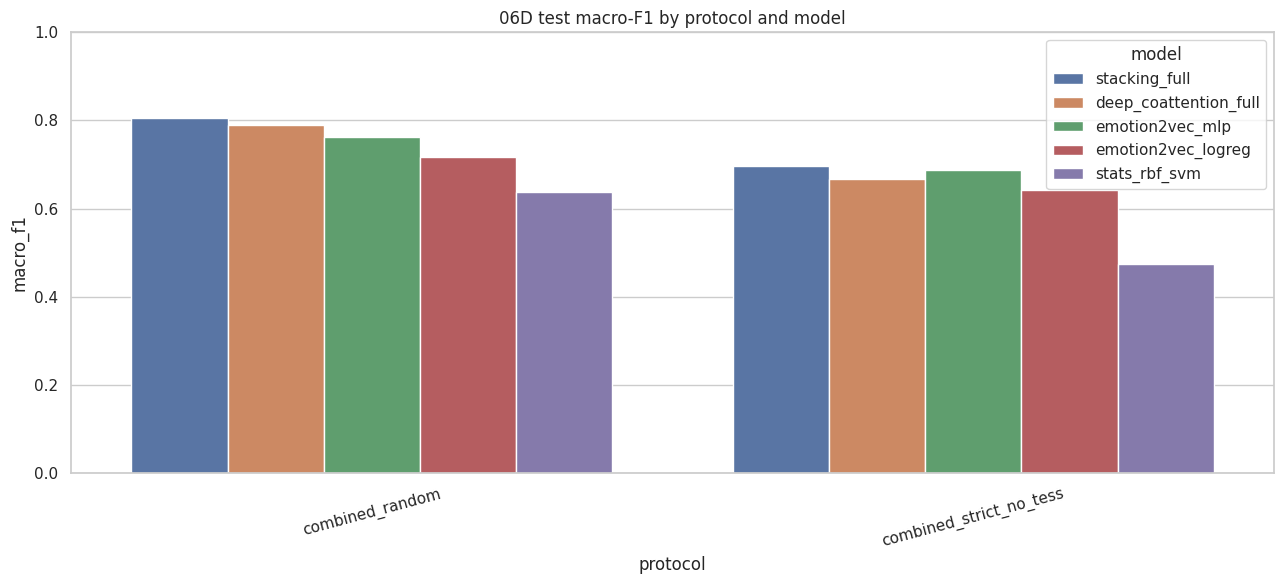

Saved: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs/figures/06D_macro_f1_leaderboard.png


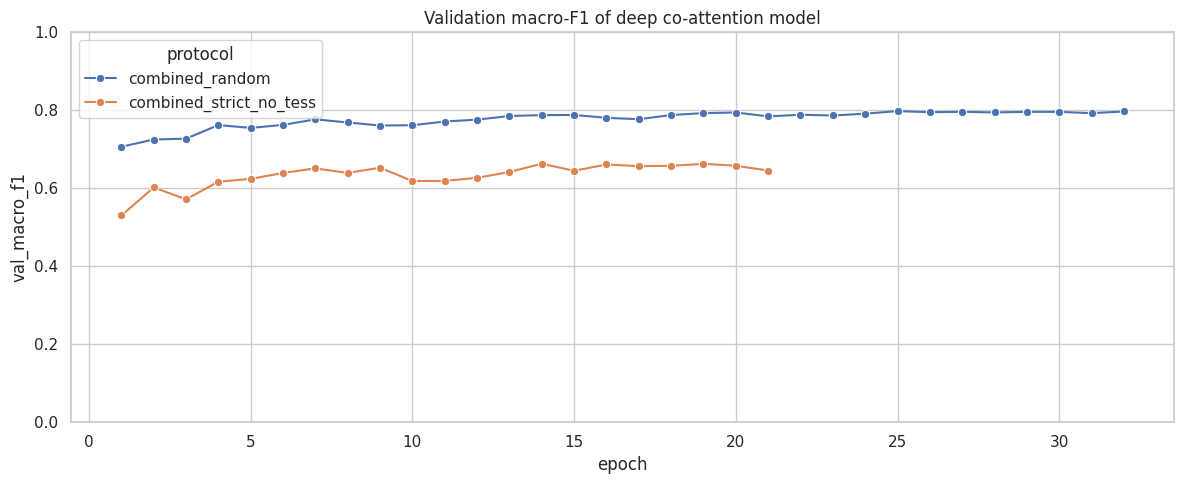

Saved: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs/figures/06D_training_curves.png


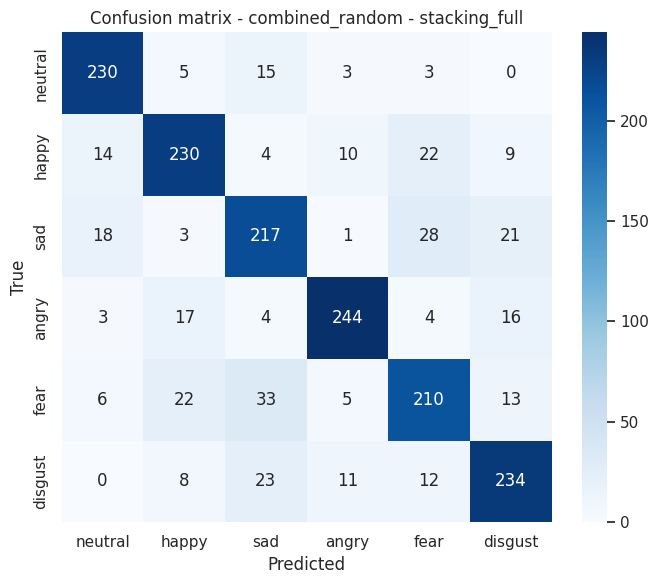

Saved: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs/figures/06D_confusion_combined_random_stacking_full.png


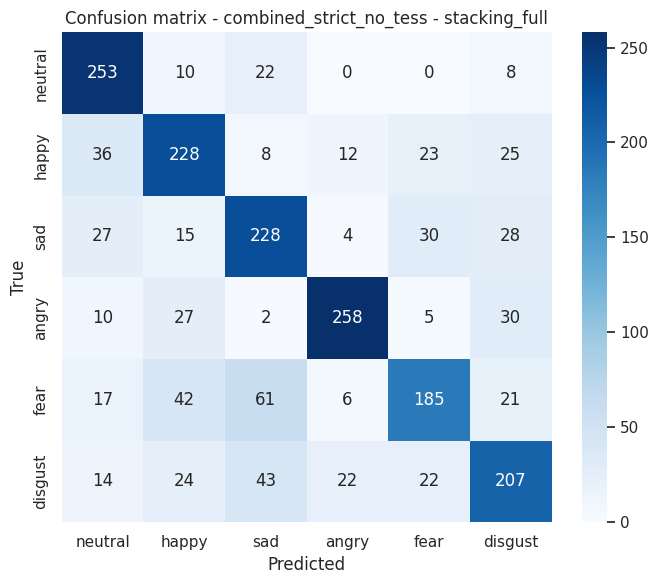

Saved: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs/figures/06D_confusion_combined_strict_no_tess_stacking_full.png


In [14]:
if len(metrics_df):
    plt.figure(figsize=(13, 6))
    plot_df = metrics_df[metrics_df["split"].eq("test")].copy()
    sns.barplot(data=plot_df, x="protocol", y="macro_f1", hue="model")
    plt.ylim(0, 1)
    plt.title("06D test macro-F1 by protocol and model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    fig_path = FIGURE_DIR / "06D_macro_f1_leaderboard.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

if len(history_df):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="protocol", marker="o")
    plt.ylim(0, 1)
    plt.title("Validation macro-F1 of deep co-attention model")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "06D_training_curves.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

for protocol_name, result_pack in protocol_results.items():
    result = result_pack["stacking"]
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.title(f"Confusion matrix - {protocol_name} - stacking_full")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    fig_path = FIGURE_DIR / f"06D_confusion_{protocol_name}_stacking_full.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)


In [15]:
reference_rows = [
    {
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "protocol": "single-dataset, split not clearly strict speaker-aware",
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "main_idea": "Handcrafted features, augmentation, recurrent CNN variants, weighted ensemble.",
        "link": "https://arxiv.org/abs/2112.05666",
    },
    {
        "model": "CA-MSER co-attention multi-level acoustic information",
        "protocol": "IEMOCAP speaker-independent style in paper; not same as our 4-corpus setup",
        "reported_accuracy_text": "Reported on IEMOCAP; use as fusion reference, not direct 6-class benchmark.",
        "main_idea": "MFCC/spectrogram/high-level embedding fusion with co-attention.",
        "link": "https://arxiv.org/abs/2203.15326",
    },
    {
        "model": "emotion2vec frozen/pretrained representation",
        "protocol": "pretrained representation; downstream varies by dataset",
        "reported_accuracy_text": "Use as representation reference; not directly comparable to our split.",
        "main_idea": "Self-supervised speech emotion representation used with lightweight downstream classifier.",
        "link": "https://arxiv.org/abs/2312.15185",
    },
    {
        "model": "Ullah et al. 1D-CNN feature fusion",
        "protocol": "combined 4-dataset, split details not fully reproducible from local materials",
        "reported_accuracy_text": "CREMA-D + RAVDESS + SAVEE + TESS: 92.62%",
        "main_idea": "ZCR + energy + entropy of energy + RMS + MFCC -> 1D-CNN.",
        "link": "https://doi.org/10.1109/ICIT56493.2022.9989197",
    },
]
ref_df = pd.DataFrame(reference_rows)
ref_df.to_csv(REPORT_DIR / "06D_reference_model_comparison.csv", index=False)
display(ref_df)


,model,protocol,reported_accuracy_text,main_idea,link
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, split not clearly strict speak...",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Handcrafted features, augmentation, recurrent ...",https://arxiv.org/abs/2112.05666
1,CA-MSER co-attention multi-level acoustic info...,IEMOCAP speaker-independent style in paper; no...,"Reported on IEMOCAP; use as fusion reference, ...",MFCC/spectrogram/high-level embedding fusion w...,https://arxiv.org/abs/2203.15326
2,emotion2vec frozen/pretrained representation,pretrained representation; downstream varies b...,Use as representation reference; not directly ...,Self-supervised speech emotion representation ...,https://arxiv.org/abs/2312.15185
3,Ullah et al. 1D-CNN feature fusion,"combined 4-dataset, split details not fully re...",CREMA-D + RAVDESS + SAVEE + TESS: 92.62%,ZCR + energy + entropy of energy + RMS + MFCC ...,https://doi.org/10.1109/ICIT56493.2022.9989197


## Save Output Package

Cell cuối đóng gói report, figure, prediction và model checkpoint. Cache feature lớn không được zip mặc định để file tải về nhẹ hơn.


In [16]:
summary = {
    "notebook": "06D_Emotion2Vec_CoAttention_Full_SER",
    "objective": "Full SER model with temporal, spectrogram, frozen emotion2vec, statistical branch, co-attention fusion and stacking.",
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(REPORT_DIR / "06D_emotion2vec_coattention_metrics.csv"),
    "history_csv": str(REPORT_DIR / "06D_emotion2vec_coattention_history.csv"),
    "per_dataset_csv": str(REPORT_DIR / "06D_emotion2vec_coattention_per_dataset.csv"),
    "protocols": [name for name, _ in protocols],
    "labels": COMMON_EMOTIONS,
    "emotion2vec_model": EMOTION2VEC_MODEL,
    "notes": "Use validation split for stacking. Test split is only used for final reporting.",
}
with open(REPORT_DIR / "06D_emotion2vec_coattention_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

# 1) Light package: small file for report review. It excludes cache.
light_zip_path = PROJECT_ROOT / "06D_Emotion2Vec_CoAttention_outputs_light_no_cache.zip"
light_package_dirs = [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR]
with zipfile.ZipFile(light_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in light_package_dirs:
        if folder.exists():
            for file_path in folder.rglob("*"):
                if file_path.is_file():
                    zf.write(file_path, file_path.relative_to(OUTPUT_DIR))

# 2) Full package: includes cache + figures + models + predictions + reports.
# This file can be large because cache may contain acoustic features and emotion2vec embeddings.
full_zip_path = PROJECT_ROOT / "06D_Emotion2Vec_CoAttention_outputs_FULL_WITH_CACHE.zip"
full_package_dirs = [CACHE_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, REPORT_DIR]
with zipfile.ZipFile(full_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in full_package_dirs:
        if folder.exists():
            for file_path in folder.rglob("*"):
                if file_path.is_file():
                    zf.write(file_path, file_path.relative_to(OUTPUT_DIR))

print("LIGHT ZIP without cache:", light_zip_path)
print("FULL ZIP with cache:", full_zip_path)
print("On Kaggle, open the right Output panel and download the zip you need.")
full_zip_path


LIGHT ZIP without cache: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs_light_no_cache.zip
FULL ZIP with cache: /kaggle/working/06D_Emotion2Vec_CoAttention_outputs_FULL_WITH_CACHE.zip
On Kaggle, open the right Output panel and download the zip you need.


PosixPath('/kaggle/working/06D_Emotion2Vec_CoAttention_outputs_FULL_WITH_CACHE.zip')